In [1]:
pip install pandas numpy matplotlib seaborn scikit-learn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_squared_error

In [3]:
np.random.seed(42)

data = pd.DataFrame({
    'Temperature': np.random.uniform(18,30,300),
    'Humidity': np.random.uniform(50,90,300),
    'CO2': np.random.uniform(300,1000,300),
    'Light_Intensity': np.random.uniform(200,900,300),
    'Nutrient_Level': np.random.uniform(1,10,300),
    'Water_Usage': np.random.uniform(2,8,300),
    'Growth_Days': np.random.randint(20,45,300)
})

# Productivity/Yield Formula
data['Yield'] = (
    0.5*data['Light_Intensity'] +
    2*data['Nutrient_Level'] +
    0.8*data['Temperature'] -
    0.3*data['Humidity'] +
    np.random.normal(0,20,300)
)

print(data.head())

   Temperature   Humidity         CO2  Light_Intensity  Nutrient_Level  \
0    22.494481  52.067269  418.254544       345.520379        7.824369   
1    29.408572  71.254185  495.013237       218.572543        1.221282   
2    26.783927  71.625405  423.907339       327.004805        1.199112   
3    25.183902  75.497196  362.091774       608.129093        3.912492   
4    19.872224  79.043653  384.445110       494.997185        5.397789   

   Water_Usage  Growth_Days       Yield  
0     5.114491           24  197.853989  
1     4.875091           39  116.309538  
2     2.153852           40  146.312641  
3     4.047487           27  291.538376  
4     4.281174           33  257.579302  


In [4]:
data.to_csv("urban_vertical_agriculture.csv", index=False)

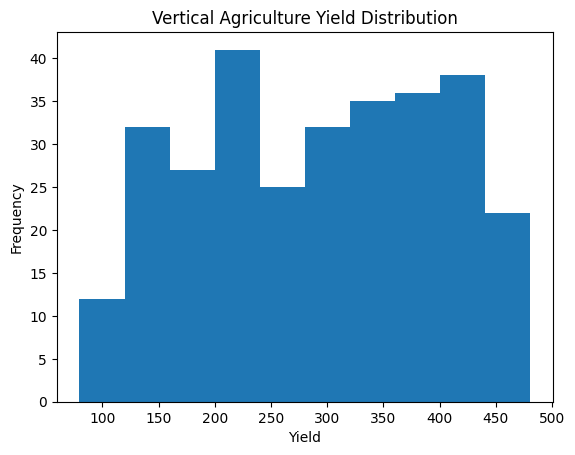

In [5]:
plt.figure()
plt.hist(data['Yield'])
plt.title("Vertical Agriculture Yield Distribution")
plt.xlabel("Yield")
plt.ylabel("Frequency")
plt.show()

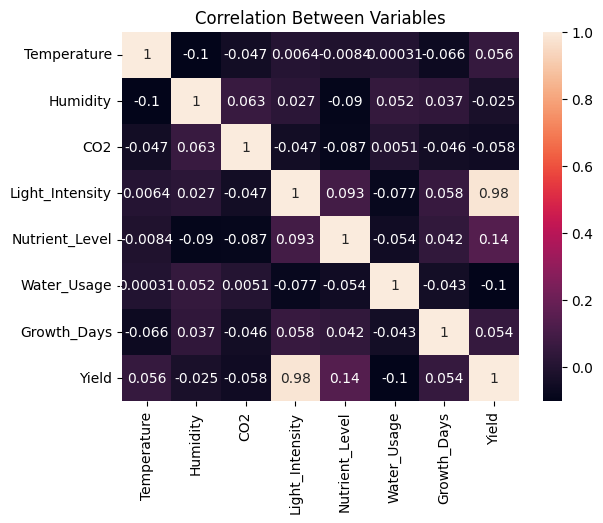

In [6]:
plt.figure()
sns.heatmap(data.corr(), annot=True)
plt.title("Correlation Between Variables")
plt.show()

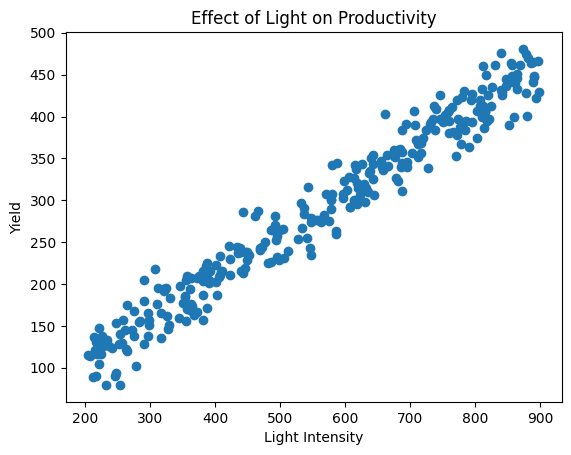

In [7]:
plt.figure()
plt.scatter(data['Light_Intensity'], data['Yield'])
plt.xlabel("Light Intensity")
plt.ylabel("Yield")
plt.title("Effect of Light on Productivity")
plt.show()

In [8]:
X = data.drop("Yield", axis=1)
y = data["Yield"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [9]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [10]:
lr = LinearRegression()
lr.fit(X_train, y_train)
pred_lr = lr.predict(X_test)

In [11]:
dt = DecisionTreeRegressor()
dt.fit(X_train, y_train)
pred_dt = dt.predict(X_test)

In [12]:
rf = RandomForestRegressor(n_estimators=100)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)

In [13]:
gb = GradientBoostingRegressor()
gb.fit(X_train, y_train)
pred_gb = gb.predict(X_test)

In [14]:
knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train, y_train)
pred_knn = knn.predict(X_test)

In [15]:
svm = SVR()
svm.fit(X_train, y_train)
pred_svm = svm.predict(X_test)

In [16]:
models = {
    "Linear Regression": pred_lr,
    "Decision Tree": pred_dt,
    "Random Forest": pred_rf,
    "Gradient Boosting": pred_gb,
    "KNN": pred_knn,
    "SVM": pred_svm
}

results = []

for name, pred in models.items():
    r2 = r2_score(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    results.append([name, r2, rmse])
    print(f"{name}: R2={r2:.3f}, RMSE={rmse:.2f}")

Linear Regression: R2=0.976, RMSE=16.47
Decision Tree: R2=0.934, RMSE=27.38
Random Forest: R2=0.967, RMSE=19.39
Gradient Boosting: R2=0.964, RMSE=20.18
KNN: R2=0.804, RMSE=47.25
SVM: R2=0.160, RMSE=97.93


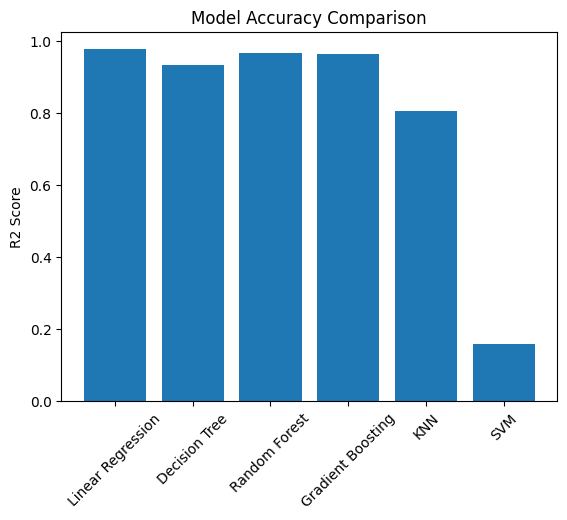

In [17]:
results_df = pd.DataFrame(results, columns=["Model","R2 Score","RMSE"])

plt.figure()
plt.bar(results_df["Model"], results_df["R2 Score"])
plt.xticks(rotation=45)
plt.title("Model Accuracy Comparison")
plt.ylabel("R2 Score")
plt.show()

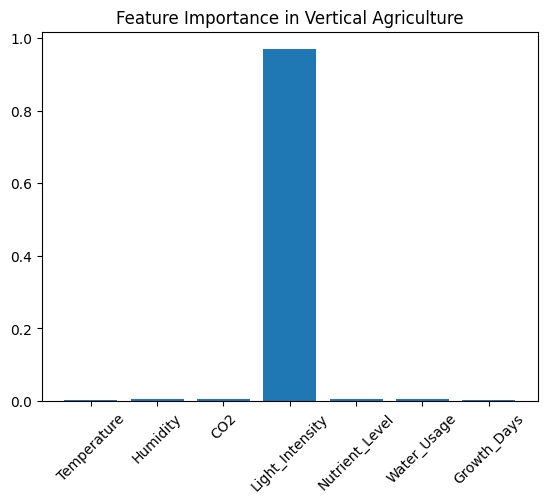

In [18]:
importance = rf.feature_importances_

plt.figure()
plt.bar(X.columns, importance)
plt.xticks(rotation=45)
plt.title("Feature Importance in Vertical Agriculture")
plt.show()

In [19]:
new_data = [[25,70,600,700,7,5,30]]

new_data_scaled = scaler.transform(new_data)

prediction = rf.predict(new_data_scaled)

print("Predicted Urban Vertical Farm Yield:", prediction[0])

Predicted Urban Vertical Farm Yield: 362.80116983944407


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
